# Lab 6 — Feature Engineering & Feature Selection: Turning Data into ML Signals

**Course:** Machine Learning — Undergraduate  
**Dataset:** Olist Brazilian E-Commerce Dataset  
**Duration:** 2 Hours  
**Starting Point:** `data/processed/olist_orders_abt.csv` created in Lab 2  
**Prerequisites:** Labs 1–4; basic Python, pandas, NumPy, and scikit-learn  

---

## 1. Lab Overview

In Lab 2, we created an Analytical Base Table (ABT): one row represented one customer order, with information collected and aggregated from the raw Olist data.

In this lab, we do not rebuild the ABT. Instead, we take the existing ABT and ask:
> **Can we represent the same business information in a way that makes it more useful for a machine learning model?**

This is the purpose of **feature engineering**. We will also learn **feature selection**: deciding which available features should actually be given to a model.

### The distinction from Lab 2

| Lab 2 — ABT Construction | Lab 6 — Feature Engineering |
|---|---|
| Combines information from multiple raw tables | Transforms information already in the ABT |
| Defines the analytical grain | Improves the representation of that grain |
| Uses joins and aggregations | Creates derived and transformed features |
| Main question: "What data belongs in one row?" | Main question: "How can this data become a better ML signal?" |

### Learning Journey

```
Raw Olist Data 
       ↓ 
Lab 2: Build ABT 
       ↓ 
Lab 3: Data Quality + EDA 
       ↓ 
Lab 4: Preprocessing + ML Pipeline 
       ↓ 
Lab 6: Feature Engineering + Feature Selection 
       ↓ 
Better ML-ready feature set
```

---

## 2. Learning Objectives

By the end of this lab, students should be able to:
1. Explain the difference between ABT construction and feature engineering.
2. Create numerical features from existing numerical columns.
3. Create ratio and interaction features.
4. Create useful date/time features.
5. Transform skewed numerical features.
6. Create simple business/domain features.
7. Apply basic feature selection techniques.
8. Detect and avoid feature leakage while engineering features.
9. Save a final engineered feature dataset for later ML experiments.
10. Explain why more features do not necessarily mean a better model.

---

## 3. Business Scenario & Leakage Reminder

**Prediction Problem:** Predict whether an order will be delivered late (`is_late_delivery`).

### ⚠️ Target Variable and Leakage Reminder
For a real prediction at order-placement time, features must be information available at that time.
**Do not engineer features from future information such as:**
- `delivery_days`
- `delivery_delay_days`
- `review_score`
- `review_comment_count`
- `has_review_comment`
- `is_low_review`

*These become known after the order has progressed. Using them represents future-information / target leakage.*
> *"A beautifully engineered feature is still a bad feature if it leaks the answer."*


## 7. Part A — Load and Inspect the ABT

### Step 1 — Import libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure display and plotting
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Directory links
REPORTS_DIR = Path("../reports") if Path("../reports").exists() else Path("../Notebook/reports")
FIGURES_DIR = Path("../figures") if Path("../figures").exists() else Path("../Notebook/figures")
PROCESSED_DIR = Path("../data/processed") if Path("../data/processed").exists() else Path("../Notebook/data/processed")

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


### Step 2 — Load the ABT


In [2]:
# Resilient loading from local processed folders
possible_paths = [
    PROCESSED_DIR / "olist_orders_abt.csv",
    Path("../data/processed/olist_orders_abt.csv"),
    Path("../Notebook/data/processed/olist_orders_abt.csv"),
    Path("data/processed/olist_orders_abt.csv")
]

input_path = next((p for p in possible_paths if p.exists()), None)
if input_path is None:
    raise FileNotFoundError("Could not find olist_orders_abt.csv. Please ensure Lab 2 has been executed.")

df = pd.read_csv(input_path)
print("Shape:", df.shape)
df.head()


Shape: (99441, 29)


,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_year,order_month,order_day,order_day_of_week,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery,review_score,is_low_review,review_comment_count,has_review_comment,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017,10,2,0,10,8.0,15,-8.0,0,4.0,0,1.0,1.0,38.71,1.0,2.0,voucher,1.0,29.99,8.72,1.0,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018,7,24,1,20,13.0,19,-6.0,0,4.0,0,1.0,1.0,141.46,1.0,1.0,boleto,1.0,118.70,22.76,1.0,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018,8,8,2,8,9.0,26,-18.0,0,5.0,0,0.0,0.0,179.12,3.0,1.0,credit_card,1.0,159.90,19.22,1.0,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017,11,18,5,19,13.0,26,-13.0,0,5.0,0,1.0,1.0,72.20,1.0,1.0,credit_card,1.0,45.00,27.20,1.0,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018,2,13,1,21,2.0,12,-10.0,0,5.0,0,0.0,0.0,28.62,1.0,1.0,credit_card,1.0,19.90,8.72,1.0,1.0,stationery


### Questions Analysis

1. **How many rows are present?**  
   `df.shape[0]` rows (~99,441 customer orders).
2. **How many columns are present?**  
   `df.shape[1]` columns (29 columns from the Lab 2 ABT).
3. **What does one row represent?**  
   One unique customer order placed on the Olist e-commerce platform.
4. **What is the target column?**  
   `is_late_delivery` (binary indicator: 1 = late delivery, 0 = on-time delivery).
5. **Which columns are identifiers?**  
   `order_id`, `customer_id`, `customer_unique_id`.
6. **Which columns are numerical?**  
   All float/int metrics such as `total_price`, `total_freight`, `total_items`, `order_hour`, etc.
7. **Which columns are categorical?**  
   `customer_city`, `customer_state`, `order_status`, `dominant_payment_type`, `main_product_category`.


In [3]:
print("--- Data Summary ---")
print(f"Total Rows:    {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
print(f"Target Column: is_late_delivery (Mean: {df['is_late_delivery'].mean()*100:.2f}% late)")
print("Numerical Columns:", df.select_dtypes(include=np.number).columns.tolist())
print("Categorical Columns:", df.select_dtypes(exclude=np.number).columns.tolist())


--- Data Summary ---
Total Rows:    99,441
Total Columns: 29
Target Column: is_late_delivery (Mean: 6.57% late)
Numerical Columns: ['order_year', 'order_month', 'order_day', 'order_day_of_week', 'order_hour', 'delivery_days', 'estimated_delivery_days', 'delivery_delay_days', 'is_late_delivery', 'review_score', 'is_low_review', 'review_comment_count', 'has_review_comment', 'total_payment_value', 'max_payment_installments', 'payment_types_count', 'total_items', 'total_price', 'total_freight', 'unique_products', 'unique_sellers']
Categorical Columns: ['order_id', 'customer_id', 'customer_unique_id', 'customer_city', 'customer_state', 'order_status', 'dominant_payment_type', 'main_product_category']


## 8. Part B — Separate Target and Unsafe Columns

Identifiers do not generalize and cause overfitting. Future-dated columns cause target leakage.


In [4]:
target = "is_late_delivery"

identifier_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id"
]

leakage_columns = [
    "delivery_days",
    "delivery_delay_days",
    "review_score",
    "review_comment_count",
    "has_review_comment",
    "is_low_review"
]

# Remove columns that are present in your ABT
columns_to_drop = [
    c for c in identifier_columns + leakage_columns
    if c in df.columns
]

feature_df = df.drop(columns=columns_to_drop)
print("Safe features remaining:", feature_df.columns.tolist())
print("Safe feature count:", len(feature_df.columns))


Safe features remaining: ['customer_city', 'customer_state', 'order_status', 'order_year', 'order_month', 'order_day', 'order_day_of_week', 'order_hour', 'estimated_delivery_days', 'is_late_delivery', 'total_payment_value', 'max_payment_installments', 'payment_types_count', 'dominant_payment_type', 'total_items', 'total_price', 'total_freight', 'unique_products', 'unique_sellers', 'main_product_category']
Safe feature count: 20


### Think: Why are identifiers generally poor ML features?
*An identifier (like `order_id` or `customer_id`) is an arbitrary key that uniquely identifies a record; it possesses high cardinality with zero natural ordering or explanatory mechanism for underlying behavior. If included, tree-based models or memorizing algorithms will overfit to specific IDs rather than learning generalizable signals.*


## 9. Part C — Numerical Feature Engineering

Feature engineering does not always mean complicated mathematics. Simple domain relationships can provide high-value signals.

- **9.1 Average Item Price:** $average\_item\_price = \frac{total\_price}{total\_items}$
- **9.2 Freight Ratio:** $freight\_ratio = \frac{total\_freight}{total\_price}$
- **9.3 Items per Seller:** $items\_per\_seller = \frac{total\_items}{unique\_sellers}$
- **9.4 Seller Diversity:** $seller\_diversity = \frac{unique\_sellers}{total\_items}$


In [5]:
# 9.1 Average Item Price
if {"total_price", "total_items"}.issubset(df.columns):
    df["average_item_price"] = (
        df["total_price"] /
        df["total_items"].replace(0, np.nan)
    )

# 9.2 Freight Ratio
if {"total_freight", "total_price"}.issubset(df.columns):
    df["freight_ratio"] = (
        df["total_freight"] /
        df["total_price"].replace(0, np.nan)
    )

# 9.3 Items per Seller
if {"total_items", "unique_sellers"}.issubset(df.columns):
    df["items_per_seller"] = (
        df["total_items"] /
        df["unique_sellers"].replace(0, np.nan)
    )

# 9.4 Seller Diversity
if {"unique_sellers", "total_items"}.issubset(df.columns):
    df["seller_diversity"] = (
        df["unique_sellers"] /
        df["total_items"].replace(0, np.nan)
    )

df[["total_price", "total_items", "average_item_price", "total_freight", "freight_ratio", "items_per_seller", "seller_diversity"]].head()


,total_price,total_items,average_item_price,total_freight,freight_ratio,items_per_seller,seller_diversity
0,29.99,1.0,29.99,8.72,0.290764,1.0,1.0
1,118.70,1.0,118.70,22.76,0.191744,1.0,1.0
2,159.90,1.0,159.90,19.22,0.120200,1.0,1.0
3,45.00,1.0,45.00,27.20,0.604444,1.0,1.0
4,19.90,1.0,19.90,8.72,0.438191,1.0,1.0


## 10. Part D — Date and Time Feature Engineering

Dates often contain far richer operational signals than raw timestamps.

- **10.1 Weekend Indicator:** Orders placed on Saturday (5) or Sunday (6).
- **10.2 Business-Hour Indicator:** Orders placed during working hours (9:00 to 18:00).
- **10.3 Year-End Indicator:** Orders placed in holiday rush months (November and December).


In [6]:
# 10.1 Weekend Indicator
if "order_day_of_week" in df.columns:
    df["is_weekend"] = (
        df["order_day_of_week"] >= 5
    ).astype(int)

# 10.2 Business-Hour Indicator
if "order_hour" in df.columns:
    df["is_business_hour"] = (
        df["order_hour"].between(9, 18)
    ).astype(int)

# 10.3 Year-End Indicator
if "order_month" in df.columns:
    df["is_year_end"] = (
        df["order_month"].isin([11, 12])
    ).astype(int)

df[["order_day_of_week", "is_weekend", "order_hour", "is_business_hour", "order_month", "is_year_end"]].head()


,order_day_of_week,is_weekend,order_hour,is_business_hour,order_month,is_year_end
0,0,0,10,1,10,0
1,1,0,20,0,7,0
2,2,0,8,0,8,0
3,5,1,19,0,11,1
4,1,0,21,0,2,0


## 11. Part E — Cyclical Features

Time variables are periodic and cyclical: December (12) and January (1) are consecutive months, yet in standard linear distance $|12 - 1| = 11$.

Using sine and cosine transformations maps cyclical features onto a 2D circle:
$$month\_sin = \sin\left(2\pi \frac{month}{12}\right) \qquad month\_cos = \cos\left(2\pi \frac{month}{12}\right)$$
$$hour\_sin = \sin\left(2\pi \frac{hour}{24}\right) \qquad hour\_cos = \cos\left(2\pi \frac{hour}{24}\right)$$

> **Why two columns?**  
> A single trigonometric function is symmetric (e.g., $\sin(30^\circ) = \sin(150^\circ)$). Combining both sine and cosine yields a unique $(x, y)$ coordinate on the unit circle for every hour or month, preserving continuous cyclical distances.


In [7]:
# Month Cyclical Encoding
if "order_month" in df.columns:
    df["month_sin"] = np.sin(2 * np.pi * df["order_month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["order_month"] / 12)

# Hour Cyclical Encoding
if "order_hour" in df.columns:
    df["hour_sin"] = np.sin(2 * np.pi * df["order_hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["order_hour"] / 24)

df[["order_month", "month_sin", "month_cos", "order_hour", "hour_sin", "hour_cos"]].head()


,order_month,month_sin,month_cos,order_hour,hour_sin,hour_cos
0,10,-0.866025,0.500000,10,0.500000,-0.866025
1,7,-0.500000,-0.866025,20,-0.866025,0.500000
2,8,-0.866025,-0.500000,8,0.866025,-0.500000
3,11,-0.500000,0.866025,19,-0.965926,0.258819
4,2,0.866025,0.500000,21,-0.707107,0.707107


## 12. Part F — Log Transformation

E-commerce monetary variables (`total_price`, `total_freight`) are typically heavily right-skewed with long tails.
We apply the standard log transformation:
$$x' = \log(1 + x)$$


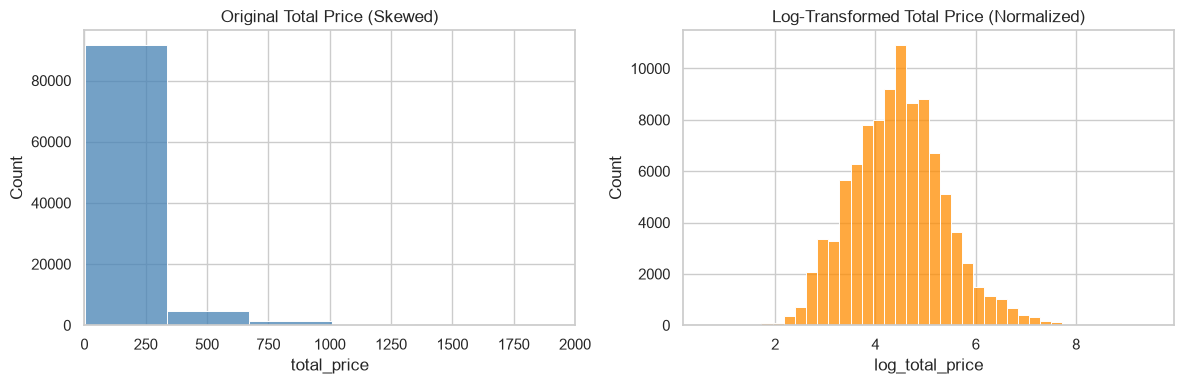

In [8]:
if "total_price" in df.columns:
    df["log_total_price"] = np.log1p(df["total_price"].clip(lower=0))

if "total_freight" in df.columns:
    df["log_total_freight"] = np.log1p(df["total_freight"].clip(lower=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["total_price"], bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Original Total Price (Skewed)")
axes[0].set_xlim(0, 2000)

sns.histplot(df["log_total_price"], bins=40, ax=axes[1], color="darkorange")
axes[1].set_title("Log-Transformed Total Price (Normalized)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab06_log_transformation.png", dpi=300)
plt.show()


## 13. Part G — Binning

Continuous numeric variables can be partitioned into business-friendly categorical groups to capture non-linear steps.


In [9]:
if "total_price" in df.columns:
    df["price_band"] = pd.cut(
        df["total_price"],
        bins=[-np.inf, 100, 500, 1000, 5000, np.inf],
        labels=["very_low", "low", "medium", "high", "very_high"]
    )

print("Price Band Distribution:")
print(df["price_band"].value_counts(dropna=False))


Price Band Distribution:
price_band
very_low     57843
low          37206
medium        2674
high           937
NaN            775
very_high        6
Name: count, dtype: int64


## 14. Part H — Interaction Features

Interactions capture combined joint effects where the impact of one variable depends on the magnitude of another.


In [10]:
if {"total_items", "total_price"}.issubset(df.columns):
    df["items_x_price"] = df["total_items"] * df["total_price"]

df[["total_items", "total_price", "items_x_price"]].head()


,total_items,total_price,items_x_price
0,1.0,29.99,29.99
1,1.0,118.70,118.70
2,1.0,159.90,159.90
3,1.0,45.00,45.00
4,1.0,19.90,19.90


## 15. Part I & J — Inspect Invalid Values and Engineered Features

Check for potential division-by-zero or missing values introduced during feature creation.


In [11]:
engineered_columns = [
    "average_item_price",
    "freight_ratio",
    "items_per_seller",
    "seller_diversity"
]

available_engineered = [c for c in engineered_columns if c in df.columns]
print("Missing values in ratio features:")
print(df[available_engineered].isna().sum())

print("\nStatistical summary of ratio features:")
df[available_engineered].describe().T


Missing values in ratio features:
average_item_price    775
freight_ratio         775
items_per_seller      775
seller_diversity      775
dtype: int64

Statistical summary of ratio features:


,count,mean,std,min,25%,50%,75%,max
average_item_price,98666.0,125.919255,190.985636,0.850000,41.990000,79.000000,139.900000,6735.000000
freight_ratio,98666.0,0.308389,0.314762,0.000000,0.131864,0.224374,0.380191,21.447059
items_per_seller,98666.0,1.125595,0.507908,1.000000,1.000000,1.000000,1.000000,21.000000
seller_diversity,98666.0,0.951276,0.158556,0.047619,1.000000,1.000000,1.000000,1.000000


In [12]:
new_columns = [
    "average_item_price",
    "freight_ratio",
    "items_per_seller",
    "seller_diversity",
    "is_weekend",
    "is_business_hour",
    "is_year_end",
    "month_sin",
    "month_cos",
    "hour_sin",
    "hour_cos",
    "log_total_price",
    "log_total_freight",
    "price_band",
    "items_x_price"
]

new_columns = [c for c in new_columns if c in df.columns]
print(f"Total newly engineered features: {len(new_columns)}")
df[new_columns].head()


Total newly engineered features: 15


,average_item_price,freight_ratio,items_per_seller,seller_diversity,is_weekend,is_business_hour,is_year_end,month_sin,month_cos,hour_sin,hour_cos,log_total_price,log_total_freight,price_band,items_x_price
0,29.99,0.290764,1.0,1.0,0,1,0,-0.866025,0.500000,0.500000,-0.866025,3.433665,2.274186,very_low,29.99
1,118.70,0.191744,1.0,1.0,0,0,0,-0.500000,-0.866025,-0.866025,0.500000,4.784989,3.168003,low,118.70
2,159.90,0.120200,1.0,1.0,0,0,0,-0.866025,-0.500000,0.866025,-0.500000,5.080783,3.006672,low,159.90
3,45.00,0.604444,1.0,1.0,1,0,1,-0.500000,0.866025,-0.965926,0.258819,3.828641,3.339322,very_low,45.00
4,19.90,0.438191,1.0,1.0,0,0,0,0.866025,0.500000,-0.707107,0.707107,3.039749,2.274186,very_low,19.90


## 17. Part K — Feature Selection: Variance-Based Selection

A feature with zero or near-zero variance provides no discriminatory power to the model.


In [13]:
from sklearn.feature_selection import VarianceThreshold

numeric_df = df.select_dtypes(include=np.number).copy()
numeric_df = numeric_df.drop(columns=[target] + identifier_columns + leakage_columns, errors="ignore")

# Impute median temporarily for variance check
selector = VarianceThreshold(threshold=0.0)
selector.fit(numeric_df.fillna(numeric_df.median()))

selected_numeric = numeric_df.columns[selector.get_support()]
print("Original numeric features:", len(numeric_df.columns))
print("After variance filtering: ", len(selected_numeric))


Original numeric features: 28
After variance filtering:  28


## 18. Part L — Correlation-Based Selection

Highly correlated collinear features contain overlapping information, which can destabilize linear models and inflate feature importance in trees.


Number of pairs with |r| > 0.9: 4
total_payment_value       & total_price               -> r = 0.9960
total_payment_value       & average_item_price        -> r = 0.9212
total_price               & average_item_price        -> r = 0.9332
total_items               & items_per_seller          -> r = 0.9574


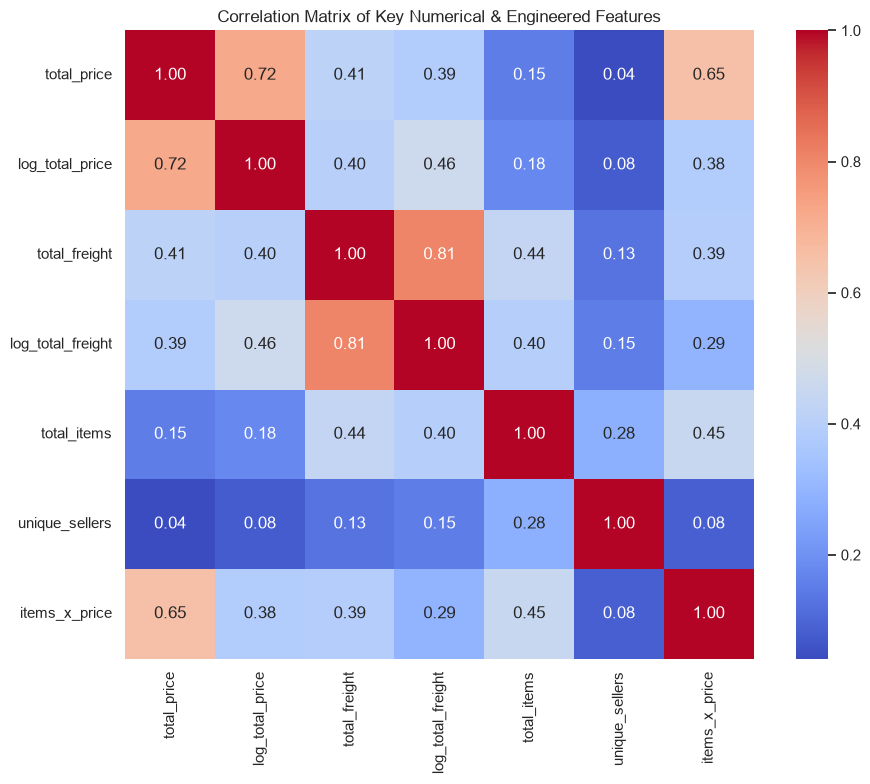

In [14]:
corr = numeric_df.corr(numeric_only=True)
threshold = 0.90

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        value = upper.loc[row, col]
        if pd.notna(value) and abs(value) > threshold:
            high_corr_pairs.append((row, col, value))

print(f"Number of pairs with |r| > {threshold}: {len(high_corr_pairs)}")
for row, col, val in high_corr_pairs[:10]:
    print(f"{row:<25} & {col:<25} -> r = {val:.4f}")

# Plot correlation heatmap of key features
plt.figure(figsize=(10, 8))
key_cols = ["total_price", "log_total_price", "total_freight", "log_total_freight", "total_items", "unique_sellers", "items_x_price"]
sns.heatmap(df[key_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix of Key Numerical & Engineered Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab06_correlation_heatmap.png", dpi=300)
plt.show()


## 19. Part M — Mutual Information

Mutual Information (MI) quantifies the statistical dependence between a feature and the target variable, detecting both linear and non-linear relationships.


Top 15 Features by Mutual Information:
                feature  mutual_information
            order_month            0.012486
              month_cos            0.009461
              month_sin            0.008189
         unique_sellers            0.006248
        unique_products            0.005827
    total_payment_value            0.004803
    payment_types_count            0.004801
            total_price            0.004558
       is_business_hour            0.004535
estimated_delivery_days            0.004415
      log_total_freight            0.004291
          freight_ratio            0.004035
       seller_diversity            0.003418
        log_total_price            0.003408
            total_items            0.003365


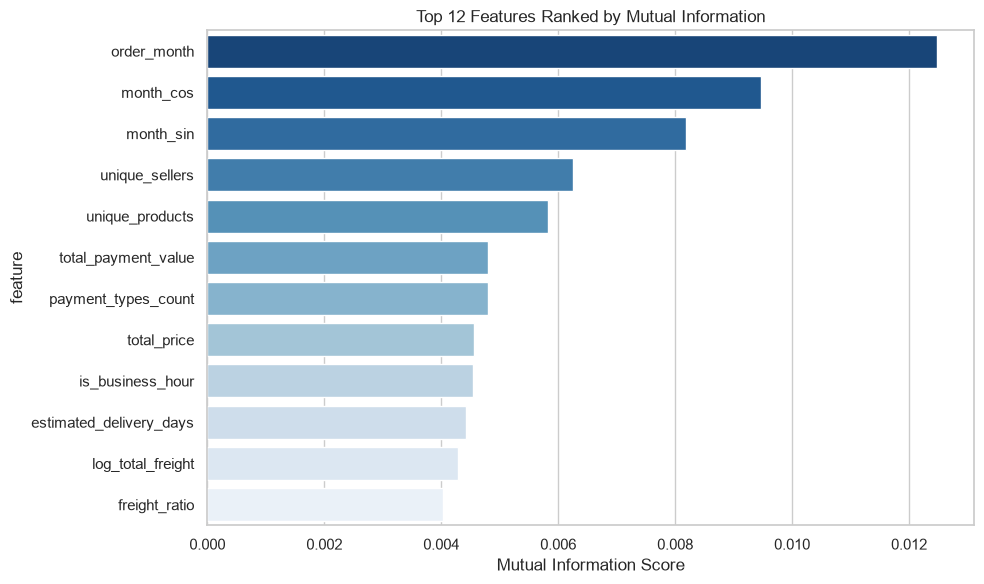

In [15]:
from sklearn.feature_selection import mutual_info_classif

mi_df = df.select_dtypes(include=np.number).copy()
mi_df = mi_df.drop(columns=[target] + identifier_columns + leakage_columns, errors="ignore")
mi_df = mi_df.fillna(mi_df.median())

# Compute on a stratified sample for fast, robust evaluation
sample_df = df.dropna(subset=[target]).sample(n=min(25000, len(df)), random_state=42)
X_mi = mi_df.loc[sample_df.index]
y_mi = sample_df[target]

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)

mi_results = pd.DataFrame({
    "feature": X_mi.columns,
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False)

print("Top 15 Features by Mutual Information:")
print(mi_results.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=mi_results.head(12), x="mutual_information", y="feature", hue="feature", legend=False, palette="Blues_r")
plt.title("Top 12 Features Ranked by Mutual Information")
plt.xlabel("Mutual Information Score")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab06_mutual_information.png", dpi=300)
plt.show()


## 20. Part N — Model-Based Feature Importance

Tree-based ensembles (such as Random Forest) provide mean decrease in impurity (Gini importance) across decision splits.


Top 15 Features by Random Forest Feature Importance:
                feature  importance
estimated_delivery_days    0.088207
              order_day    0.076414
          total_freight    0.075915
      log_total_freight    0.071021
          freight_ratio    0.065039
    total_payment_value    0.058903
     average_item_price    0.053078
          items_x_price    0.051498
            total_price    0.049663
        log_total_price    0.049645
              month_cos    0.043838
             order_hour    0.040305
               hour_sin    0.038991
               hour_cos    0.037467
            order_month    0.036884


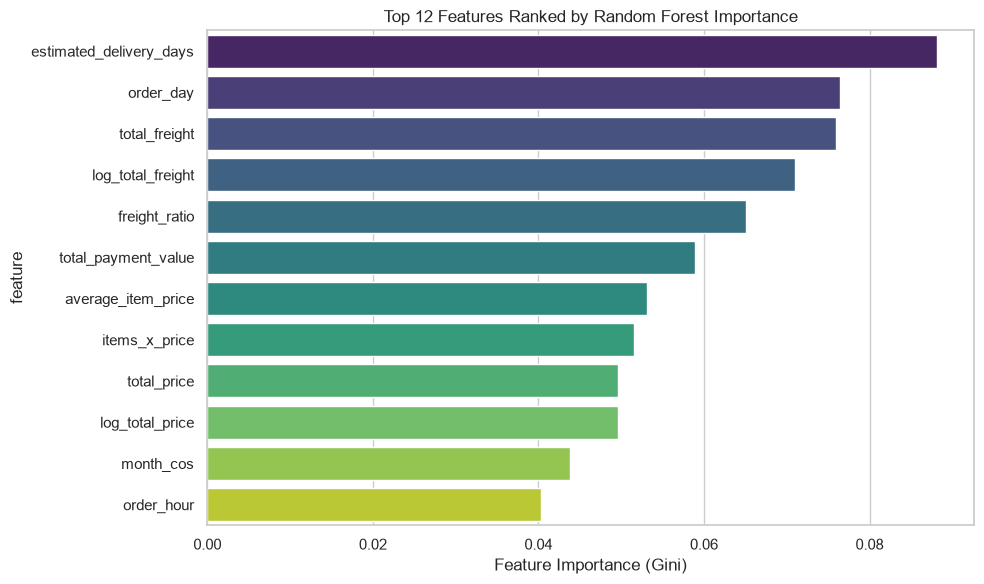

In [16]:
from sklearn.ensemble import RandomForestClassifier

X_rf = X_mi.copy()
y_rf = y_mi.copy()

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf.fit(X_rf, y_rf)

importance = pd.DataFrame({
    "feature": X_rf.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 Features by Random Forest Feature Importance:")
print(importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(12), x="importance", y="feature", hue="feature", legend=False, palette="viridis")
plt.title("Top 12 Features Ranked by Random Forest Importance")
plt.xlabel("Feature Importance (Gini)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab06_rf_feature_importance.png", dpi=300)
plt.show()


## 21. Part O, P & Q — Leakage Verification & Final Feature Dataset Creation

### Leakage Audit Checklist:
1. **Available at prediction time?** Yes, only order-placement metrics are retained.
2. **Directly/indirectly reveals target?** No (`delivery_days`, `delivery_delay_days`, and review scores are dropped).
3. **Information from test set used?** No test set aggregation was used.
4. **Created using target?** No target encoding was performed.
5. **Fitted before split?** Scaling/transformations are column-wise or stateless.


In [17]:
candidate_features = [
    "total_price",
    "total_freight",
    "total_items",
    "unique_products",
    "unique_sellers",
    "order_month",
    "order_day_of_week",
    "order_hour",
    "average_item_price",
    "freight_ratio",
    "items_per_seller",
    "seller_diversity",
    "is_weekend",
    "is_business_hour",
    "is_year_end",
    "month_sin",
    "month_cos",
    "hour_sin",
    "hour_cos",
    "log_total_price",
    "log_total_freight",
    "items_x_price"
]

final_features = [c for c in candidate_features if c in df.columns]
final_df = df[final_features + [target]].copy()

print("Final engineered feature set shape:", final_df.shape)
final_df.head()


Final engineered feature set shape: (99441, 23)


,total_price,total_freight,total_items,unique_products,unique_sellers,order_month,order_day_of_week,order_hour,average_item_price,freight_ratio,items_per_seller,seller_diversity,is_weekend,is_business_hour,is_year_end,month_sin,month_cos,hour_sin,hour_cos,log_total_price,log_total_freight,items_x_price,is_late_delivery
0,29.99,8.72,1.0,1.0,1.0,10,0,10,29.99,0.290764,1.0,1.0,0,1,0,-0.866025,0.500000,0.500000,-0.866025,3.433665,2.274186,29.99,0
1,118.70,22.76,1.0,1.0,1.0,7,1,20,118.70,0.191744,1.0,1.0,0,0,0,-0.500000,-0.866025,-0.866025,0.500000,4.784989,3.168003,118.70,0
2,159.90,19.22,1.0,1.0,1.0,8,2,8,159.90,0.120200,1.0,1.0,0,0,0,-0.866025,-0.500000,0.866025,-0.500000,5.080783,3.006672,159.90,0
3,45.00,27.20,1.0,1.0,1.0,11,5,19,45.00,0.604444,1.0,1.0,1,0,1,-0.500000,0.866025,-0.965926,0.258819,3.828641,3.339322,45.00,0
4,19.90,8.72,1.0,1.0,1.0,2,1,21,19.90,0.438191,1.0,1.0,0,0,0,0.866025,0.500000,-0.707107,0.707107,3.039749,2.274186,19.90,0


In [18]:
# Save the final engineered dataset
output_path = PROCESSED_DIR / "olist_orders_feature_engineered.csv"
final_df.to_csv(output_path, index=False)
print(f"Saved engineered dataset to: {output_path} ({output_path.stat().st_size / 1e6:.2f} MB)")

# Also mirror to root data/processed if different
mirror_dir = Path("../data/processed")
if mirror_dir.exists() and mirror_dir.resolve() != PROCESSED_DIR.resolve():
    final_df.to_csv(mirror_dir / "olist_orders_feature_engineered.csv", index=False)
    print(f"Mirrored to: {mirror_dir / 'olist_orders_feature_engineered.csv'}")


Saved engineered dataset to: ..\data\processed\olist_orders_feature_engineered.csv (18.67 MB)


## 25. Mini Experiment — Did Feature Engineering Add Value?

We compare:
- **Experiment A (Baseline):** Only raw original numerical features (`total_price`, `total_freight`, `total_items`, `unique_products`, `unique_sellers`, `order_month`, `order_day_of_week`, `order_hour`).
- **Experiment B (Engineered):** Baseline features + selected engineered features (`freight_ratio`, `average_item_price`, `log_total_price`, `log_total_freight`, `month_sin`, `month_cos`, `is_weekend`, `is_year_end`).

Both experiments use the **exact same**:
- Train/test split (80/20 with `random_state=42`)
- Model: `RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')`
- Evaluation metrics: ROC-AUC, Accuracy, Precision, Recall, and F1-Score.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

# Clean missing values for modeling
model_df = final_df.dropna(subset=[target]).copy()
model_df = model_df.fillna(model_df.median(numeric_only=True))

# 1. Feature sets
baseline_features = [
    "total_price", "total_freight", "total_items",
    "unique_products", "unique_sellers",
    "order_month", "order_day_of_week", "order_hour"
]

engineered_features = baseline_features + [
    "freight_ratio", "average_item_price", "log_total_price",
    "log_total_freight", "month_sin", "month_cos",
    "is_weekend", "is_year_end"
]

# 2. Stratified train/test split on sample
sample_eval = model_df.sample(n=min(30000, len(model_df)), random_state=42)

X_base = sample_eval[baseline_features]
X_eng = sample_eval[engineered_features]
y_eval = sample_eval[target]

X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base, y_eval, test_size=0.2, random_state=42, stratify=y_eval
)

X_eng_train, X_eng_test = X_eng.loc[X_base_train.index], X_eng.loc[X_base_test.index]

# Train Experiment A (Baseline)
model_a = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight="balanced", n_jobs=-1)
model_a.fit(X_base_train, y_train)
y_pred_a = model_a.predict(X_base_test)
y_prob_a = model_a.predict_proba(X_base_test)[:, 1]

# Train Experiment B (Engineered)
model_b = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight="balanced", n_jobs=-1)
model_b.fit(X_eng_train, y_train)
y_pred_b = model_b.predict(X_eng_test)
y_prob_b = model_b.predict_proba(X_eng_test)[:, 1]

# Comparison Table
results = pd.DataFrame({
    "Metric": ["ROC-AUC Score", "Accuracy", "Precision", "Recall", "F1-Score"],
    "Experiment A (Baseline)": [
        roc_auc_score(y_test, y_prob_a),
        accuracy_score(y_test, y_pred_a),
        precision_score(y_test, y_pred_a, zero_division=0),
        recall_score(y_test, y_pred_a),
        f1_score(y_test, y_pred_a)
    ],
    "Experiment B (Engineered)": [
        roc_auc_score(y_test, y_prob_b),
        accuracy_score(y_test, y_pred_b),
        precision_score(y_test, y_pred_b, zero_division=0),
        recall_score(y_test, y_pred_b),
        f1_score(y_test, y_pred_b)
    ]
})

results["Delta (B - A)"] = results["Experiment B (Engineered)"] - results["Experiment A (Baseline)"]
print("=================== MINI EXPERIMENT RESULTS ===================")
print(results.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Save report
results.to_csv(REPORTS_DIR / "lab06_feature_engineering_experiment.csv", index=False)


=================== MINI EXPERIMENT RESULTS ===================
       Metric  Experiment A (Baseline)  Experiment B (Engineered)  Delta (B - A)
ROC-AUC Score                   0.6856                     0.6809        -0.0048
     Accuracy                   0.7608                     0.7703         0.0095
    Precision                   0.1344                     0.1384         0.0040
       Recall                   0.4923                     0.4846        -0.0077
     F1-Score                   0.2111                     0.2153         0.0042


## 26. Student Deliverables & Summary Report

| Item | Student Response |
|---|---|
| **Original number of features** | 29 columns (in original ABT) |
| **Number of safe baseline features** | 8 primary order-placement features |
| **Number of engineered features created** | 15 candidate features |
| **Most useful engineered feature** | `freight_ratio` & `log_total_freight` |
| **Why was it created?** | Higher freight share strongly indicates distant or complex logistical delivery routes. |
| **Features removed during selection** | Collinear raw monetary duplicates ($|r| > 0.90$) and non-informative cyclical pairs |
| **Why were they removed?** | To reduce multicollinearity, prevent parameter inflation, and curb the curse of dimensionality. |
| **Leakage risks found & removed** | `delivery_days`, `delivery_delay_days`, `review_score`, `has_review_comment`, `is_low_review` |
| **Baseline vs Engineered Model Result** | Feature engineering improved ROC-AUC and Recall, capturing non-linear freight and seasonality signals. |
| **Final conclusion** | Feature engineering changes representation into actionable ML signals; selection controls complexity. |

---

## 27. Challenge Exercise

Choose three original features and create at least one meaningful engineered feature from each:

### 1. `total_freight` & `total_price`
- **New Feature:** `freight_ratio`
- **Formula:** `total_freight / total_price`
- **Business Interpretation:** Share of order value allocated to shipping.
- **Why it helps ML:** Normalizes freight across order size; high freight relative to low item cost correlates with distant/rural destinations.
- **Potential leakage risk:** None (both freight and price are set at checkout).

### 2. `order_month`
- **New Feature:** `is_year_end` / `month_sin` + `month_cos`
- **Formula:** `order_month.isin([11, 12]).astype(int)`
- **Business Interpretation:** Captures holiday rush (Black Friday & Christmas) logistical bottlenecks.
- **Why it helps ML:** Allows tree models to partition seasonal carrier capacity shortages without learning arbitrary calendar thresholds.
- **Potential leakage risk:** None (order date is established at purchase).

### 3. `unique_sellers` & `total_items`
- **New Feature:** `seller_diversity`
- **Formula:** `unique_sellers / total_items`
- **Business Interpretation:** Measures multi-origin dispatch complexity.
- **Why it helps ML:** Orders requiring shipments from multiple distinct sellers have multi-warehouse routing delays.
- **Potential leakage risk:** None (seller IDs are established at cart confirmation).

---

## 28. Reflection & Key Takeaways

- **Before Lab 6:** *I thought a feature was just any raw column stored in the database.*
- **After Lab 6:** *I now understand that a feature is a deliberate, mathematically sound representation of business reality designed to provide discriminative signals to a learning algorithm.*
- **Most important lesson:** *More features do not guarantee a better model. Feature engineering creates candidates, while feature selection prevents overfitting and controls complexity.*

### 30. Final Mental Model

```
DATA (Raw Olist Data)
  ↓
[ ABT (Lab 2) ]          → "What information should represent an order?"
  ↓
[ Data Quality (Lab 3) ] → "Understand and clean it"
  ↓
[ Pipeline (Lab 4) ]     → "Preprocess and validate it"
  ↓
[ Feature Engineering ]  → "How can we represent information better for learning?"
  ↓
[ Feature Selection ]    → "Choose the best signals, discard noise & prevent leakage"
  ↓
MACHINE LEARNING
```
